Define Mean bias, Skill score

In [1]:
import pandas as pd
import xarray as xr
import xcdat as xc
import numpy as np
import os
import glob
import re
import cftime

/global/homes/j/jungchoi/.conda/envs/pcmdi_metrics/lib/python3.10/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


In [2]:
def compute_acc_msss_rmse(x: xr.DataArray, y: xr.DataArray):
    """
    ACC (Anomaly Correlation Coefficient) and MSSS (Mean Squared Skill Score)

    Parameters:
        x (xr.DataArray): model anomalies
        y (xr.DataArray): observed anomalies

    Returns:
        acc (xr.DataArray): ACC 
        msss (xr.DataArray): MSSS 
    """
    x_std = x.std(dim="time")
    y_std = y.std(dim="time")
    cov = (x * y).mean(dim="time")

    acc = cov / (x_std * y_std)
    msss = acc**2 - (acc - x_std / y_std)**2
    rmse = np.sqrt(((x - y) ** 2).mean(dim="time"))

    return acc, msss, rmse


In [6]:
print("%%%%%%%% start to calculate skill score %%%%%%%")

output_dir = "/pscratch/sd/j/jungchoi/DCPP/_metrics"
output_grid = xc.regridder.grid.create_uniform_grid(-88.75, 88.75, 2.5, 0.0, 357.5, 2.5)
output_grid_no = "144x72"

#var_name = "tas"
#comm_year_start = 1965
#comm_year_end = 2014

var_name = "pr"
comm_year_start = 1979
comm_year_end = 2014

clim_period = "1981-2010"
exp_in = f"historical.1961-2014"
exp_out = f"historical.{comm_year_start}-{comm_year_end}"


%%%%%%%% start to calculate skill score %%%%%%%


In [7]:
# Historical exp. skill scores

mdl_list = ['CanESM5', 'CMCC-CM2-SR5', 'CNRM-ESM2-1', 'EC-Earth3', 'FGOALS-f3-L', 'HadGEM3-GC31-MM', 'IPSL-CM6A-LR', 'MIROC6', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'NorCPM1', 'MME']
#mdl_list = ['MME']
#mdl_list = ['CanESM5']

# Read observation climatology
obs_file = f"{output_dir}/OBS/{var_name}.{output_grid_no}.mon_clim{clim_period}.nc"    
ds = xr.open_dataset(obs_file)
obs_clim = ds.mean(dim="month")
ds.close()

# Read observation data (annual mean)
if var_name == "tas":
    obs_ann_file = f"{output_dir}/OBS/{var_name}.{output_grid_no}.1961-2021.ann.nc"
if var_name == "pr":
    obs_ann_file = f"{output_dir}/OBS/{var_name}.{output_grid_no}.1979-2021.ann.nc"

obs_ann = xr.open_dataset(obs_ann_file)
obs_ann.close()

target_year_start = comm_year_start 
target_year_end   = comm_year_end
target_years = list(range(target_year_start, target_year_end + 1))

for model in mdl_list[0:13]:   
    ensemble_no = 10
    if model == "FGOALS-f3-L" :
        ensemble_no = 3
    if model == "HadGEM3-GC31-MM" :
        ensemble_no = 4
    if model == "MME" :
        ensemble_no = 97
 
    # Read model climatology and define bias
    if model != "MME":
        mdl_file = f"{output_dir}/{model}/{var_name}.{output_grid_no}.historical.mon_clim{clim_period}.em.nc"    
        ds = xr.open_dataset(mdl_file)
        mdl_clim = ds.mean(dim="month")
        ds.close()

        bias = mdl_clim[f"{var_name}"] - obs_clim[f"{var_name}"]
        
        mdl_file = f"{output_dir}/{model}/{var_name}.{output_grid_no}.{exp_in}.r1-{ensemble_no}.nc"    
        ds = xr.open_dataset(mdl_file)
        ei = ds - bias
        em = ds.mean(dim="ensemble") - bias
        ds.close()

    if model == "MME":
        mdl_file = f"{output_dir}/{model}/{var_name}_bc.{output_grid_no}.{exp_in}.r1-{ensemble_no}.nc"    
        ds = xr.open_dataset(mdl_file)
        ei = ds 
        em = ds.mean(dim="ensemble") 
        ds.close()
    
    xi_list = []
    x_list = []
    y_list = []
    
    # selected target years
    mei_ds = ei.sel(time=ei.time.dt.year.isin(target_years)) 
    mem_ds = em.sel(time=em.time.dt.year.isin(target_years)) 
    obs_ds = obs_ann.sel(time=obs_ann.time.dt.year.isin(target_years))

    print('%%% Model time==', mem_ds.time.dt.year)
    print('%%% OBS time==', obs_ds.time.dt.year)
    
    # Compute skill scores and std for ensemble-mean 
    x = mem_ds[f"{var_name}"] - mem_ds[f"{var_name}"].mean(dim="time")
    y = obs_ds[f"{var_name}"] - obs_ds[f"{var_name}"].mean(dim="time")
    
    acc, msss, rmse = compute_acc_msss_rmse(x,y)
    pc_obs = acc
    sig_std = x.std(dim="time")

    # Compute the predictable components in model
    xi_ds = []
    stdi_ds = []
    for i in range(mei_ds.sizes['ensemble']):
        xi = mei_ds[f"{var_name}"].isel(ensemble=i) - mem_ds[f"{var_name}"].mean(dim="time")
        xi_std = xi.std(dim="time")
        stdi_ds.append(xi_std)
        xi_ds.append(xi)
        
    stdi_all = xr.concat(stdi_ds, dim="ensemble")
    xi_all = xr.concat(xi_ds, dim="ensemble")

    pc_mdl = sig_std / stdi_all.mean(dim="ensemble") 
    rpc = pc_obs / pc_mdl
    ##rpc = rpc.where(acc > 0)
    
    acc.name = "acc"
    msss.name = "msss"
    rmse.name = "rmse"
    rpc.name = "rpc"
    sig_std.name = "std"
    pc_mdl.name = "pcm"

    skill_scores = xr.Dataset({"acc": acc, "msss": msss, "rmse": rmse, "rpc": rpc, "std": sig_std, "pcm": pc_mdl})
 
    output_filename = f"{output_dir}/{model}/skill_scores6.{var_name}.{output_grid_no}.{exp_out}.ann.em.nc"
    if os.path.exists(output_filename):
        os.remove(output_filename)
    skill_scores.to_netcdf(output_filename)
    #print('%%% leadtime, skill=', lead_year, skill_scores)
    print(f"%% Skill Scores dataset saved: {output_filename}")

###########################################################
    ###### Make YR1-YR5 averaged datasets  
    #print('before==', xi_all)
    xi_mean = xi_all.rolling(time=5, center=False).mean().shift(time=-4)
    x_mean = x.rolling(time=5, center=False).mean().shift(time=-4)
    y_mean = y.rolling(time=5, center=False).mean().shift(time=-4)

    xi_mean = xi_mean.dropna(dim='time')
    x_mean = x_mean.dropna(dim='time')
    y_mean = y_mean.dropna(dim='time')

    #print('after==', xi_all)

    acc, msss, rmse = compute_acc_msss_rmse(x_mean,y_mean)
    pc_obs = acc
    sig_std = x_mean.std(dim="time")
            
    # Compute the predictable components in model
    stdi_ds = []
    for i in range(mei_ds.sizes['ensemble']):
        xii = xi_mean.isel(ensemble=i)
        xi_std = xii.std(dim="time")
        stdi_ds.append(xi_std)
    stdi_all = xr.concat(stdi_ds, dim="ensemble")
    
    pc_mdl = sig_std / stdi_all.mean(dim="ensemble") 
    rpc = pc_obs / pc_mdl
    ##rpc = rpc.where(acc > 0)
    
    acc.name = "acc"
    msss.name = "msss"
    rmse.name = "rmse"
    rpc.name = "rpc"
    sig_std.name = "std"
    pc_mdl.name = "pcm"
    
    skill_scores = xr.Dataset({"acc": acc, "msss": msss, "rmse": rmse, "rpc": rpc, "std": sig_std, "pcm": pc_mdl})
    print('%%%SKill score==', skill_scores)
    
    output_filename = f"{output_dir}/{model}/skill_scores6.{var_name}.{output_grid_no}.{exp_out}.ann5.em.nc"
    if os.path.exists(output_filename):
        os.remove(output_filename)
    skill_scores.to_netcdf(output_filename)
    print(skill_scores)
    print(f"%% 5yr Skill Scores dataset saved: {output_filename}")  
    
        

%%% Model time== <xarray.DataArray 'year' (time: 36)> Size: 288B
array([1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989,
       1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000,
       2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
       2012, 2013, 2014])
Coordinates:
  * time     (time) datetime64[ns] 288B 1979-01-01 1980-01-01 ... 2014-01-01
%%% OBS time== <xarray.DataArray 'year' (time: 36)> Size: 288B
array([1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989,
       1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000,
       2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
       2012, 2013, 2014])
Coordinates:
  * time     (time) datetime64[ns] 288B 1979-01-01 1980-01-01 ... 2014-01-01
%% Skill Scores dataset saved: /pscratch/sd/j/jungchoi/DCPP/_metrics/CanESM5/skill_scores6.pr.144x72.historical.1979-2014.ann.em.nc
%%%SKill score== <xarray.Dataset> Size: 251kB
Dimensions:  (lat: 72, l

<xarray.Dataset> Size: 251kB
Dimensions:  (lat: 72, lon: 144)
Coordinates:
  * lat      (lat) float64 576B -88.75 -86.25 -83.75 ... 83.75 86.25 88.75
  * lon      (lon) float64 1kB 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
Data variables:
    acc      (lat, lon) float32 41kB 0.1408 0.1452 0.1407 ... 0.7329 0.7385
    msss     (lat, lon) float32 41kB -0.2147 -0.2061 -0.2151 ... 0.483 0.4939
    rmse     (lat, lon) float32 41kB 0.4942 0.4928 0.495 ... 0.683 0.6754 0.6682
    rpc      (lat, lon) float32 41kB 0.2231 0.2311 0.2233 ... 0.8413 0.8484
    std      (lat, lon) float32 41kB 0.2802 0.279 0.2808 ... 0.9063 0.9061
    pcm      (lat, lon) float32 41kB 0.631 0.6286 0.6303 ... 0.872 0.8711 0.8705


NameError: name 'mdl_var_name' is not defined

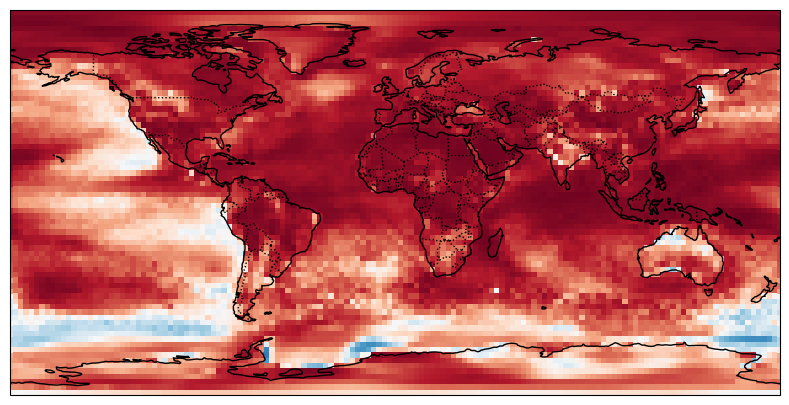

In [5]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors

#skill_scores = skill_scores.squeeze(dim="leadtime")
print(skill_scores)
data0 = skill_scores

data = data0["acc"].values
lon = data0["lon"].values
lat = data0["lat"].values


# Create figure and axis with PlateCarree projection
fig, ax = plt.subplots(figsize=(10, 5), subplot_kw={'projection': ccrs.PlateCarree()})

# Add coastlines for reference
ax.add_feature(cfeature.COASTLINE, linewidth=1)
ax.add_feature(cfeature.BORDERS, linestyle=":")


# Define normalization to center at zero
#norm = mcolors.TwoSlopeNorm(vmin=data.min(), vcenter=0, vmax=data.max())
#norm = mcolors.TwoSlopeNorm(vmin=-5, vcenter=0, vmax=5)
norm = mcolors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

# Use "RdBu_r" colormap for smooth gradation from blue → white → red
mesh = ax.pcolormesh(lon, lat, data, transform=ccrs.PlateCarree(),
                      cmap="RdBu_r", norm=norm)

# Plot the climatology data
#mesh = ax.pcolormesh(lon, lat, data, transform=ccrs.PlateCarree(), cmap="coolwarm")
#contour = ax.contour(lon, lat, data, levels=np.arange(-20, 20, 1.0), 
#                     colors="black", linewidths=0.8, transform=ccrs.PlateCarree())

# Add contour labels
#ax.clabel(contour, inline=True, fontsize=8, fmt="%1.0f")

# Add colorbar
#cbar = plt.colorbar(mesh, ax=ax, orientation="vertical", pad=0.02)
#cbar.set_label("SST (°C)")

# Set title
ax.set_extent([lon.min(), lon.max(), -90, 90], crs=ccrs.PlateCarree())
ax.set_title(f"{model} {mdl_var_name} ACC (Lead Time {lead_year})")

pos = ax.get_position()  # Get axis position
cbar_ax = fig.add_axes([pos.x1 + 0.02, pos.y0, 0.02, pos.y1 - pos.y0])  # Align with figure
cbar = plt.colorbar(mesh, cax=cbar_ax)
#cbar.set_label("TAS (°C)")  # Modify label if needed

# Show plot
plt.show()
